# Entrenamiento vs inferencia: el sobreajuste, en directo

**Facsímil 1 · Los cimientos** — capítulo 10 (entrenamiento frente a inferencia).

Este cuaderno trata del error más común y más caro del *machine learning*, el que hace que demos
deslumbrantes se estrellen en producción: confundir **memorizar** con **aprender**. Un modelo que se
sabe los datos de entrenamiento de memoria puede tener un error bajísimo... y fracasar con cualquier
dato nuevo. Vas a provocar ese fenómeno a propósito, a medirlo, a entender por qué ocurre (el famoso
compromiso **sesgo-varianza**) y a combatirlo con dos herramientas que usarás toda tu vida:
**regularización** y **validación cruzada**.

### Qué vas a aprender
- La diferencia operativa entre **entrenar** (ajustar con datos vistos) e **inferir** (predecir con
  datos nuevos), y por qué solo lo segundo cuenta.
- A reconocer **infraajuste** (modelo demasiado simple) y **sobreajuste** (demasiado complejo) de un
  vistazo.
- La **curva en U** del error de prueba y qué la causa (sesgo vs varianza).
- Cómo **más datos** y la **regularización** domestican el sobreajuste, con experimentos que ejecutas.
- Por qué la **validación cruzada** es la forma honesta de elegir la complejidad.

### Cuánto cuesta
Unos 12 minutos. CPU, sin GPU ni claves.


> **Inteligencia artificial para gente curiosa** · facsímil interactivo
> 
> Web del facsímil: https://www.iaparagentecuriosa.686f6c61.dev/ · Autor: @686f6c61 · Fecha: 2026-06-26 · Versión 1.0
> 
> Este cuaderno acompaña al facsímil: ejecútalo de arriba abajo, lee cada celda de texto
> antes de correr la de código y detente en las salidas. La gracia no es que «salga», sino
> entender *por qué* sale.

In [1]:
# Colab ya lo trae. En tu maquina:  pip install numpy matplotlib scikit-learn
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import cross_val_score

np.random.seed(3)

def modelo_grado(grado, alpha=0.0):
    # Escalamos las potencias (si no, x**15 dispara los numeros). alpha>0 = regularizacion (Ridge).
    reg = Ridge(alpha=alpha) if alpha > 0 else LinearRegression()
    return make_pipeline(PolynomialFeatures(grado), StandardScaler(), reg)

print("Listo.")


Listo.


## 1. Aprender no es memorizar

Imagina un estudiante que se aprende de memoria las respuestas de los exámenes de años pasados. En un
examen idéntico sacaría un 10. Pero si le cambias una pregunta, se hunde: no entendió nada, solo
memorizó. Con los modelos pasa igual. Por eso, para saber si un modelo *aprendió*, no se le evalúa con
los datos que ya vio (eso sería repetirle el examen), sino con datos **nuevos** que apartamos antes de
entrenar: el conjunto de **prueba** (*test*).

- **Entrenar:** ajustar los parámetros usando los datos de entrenamiento.
- **Inferir / generalizar:** predecir bien con datos que el modelo nunca vio.

La regla de oro: **el test no se toca durante el entrenamiento.** Es el examen sorpresa. Vamos a
generar datos a partir de una curva conocida más ruido, para poder comparar contra la «verdad».


In [2]:
def verdad(x):
    return np.sin(1.4 * x) + 0.3 * x        # la relacion real, suave

N = 30
x = np.sort(np.random.uniform(0, 5, N))
y = verdad(x) + np.random.normal(0, 0.35, N)   # medicion = verdad + ruido

idx = np.random.permutation(N)
tr, te = idx[:20], idx[20:]
x_tr, y_tr = x[tr], y[tr]
x_te, y_te = x[te], y[te]
print(f"{len(tr)} puntos para ENTRENAR, {len(te)} para EVALUAR (que el modelo NO vera al entrenar).")


20 puntos para ENTRENAR, 10 para EVALUAR (que el modelo NO vera al entrenar).


## 2. Tres modelos: poco, lo justo y demasiado

Ajustamos polinomios de grado creciente. Un grado bajo (1, una recta) es demasiado rígido para una
curva: se queda corto (**infraajuste**). Un grado altísimo (15) tiene tanta libertad que pasa por
*todos* los puntos de entrenamiento... incluido el **ruido**, inventándose contorsiones entre ellos
(**sobreajuste**). En medio está la virtud.


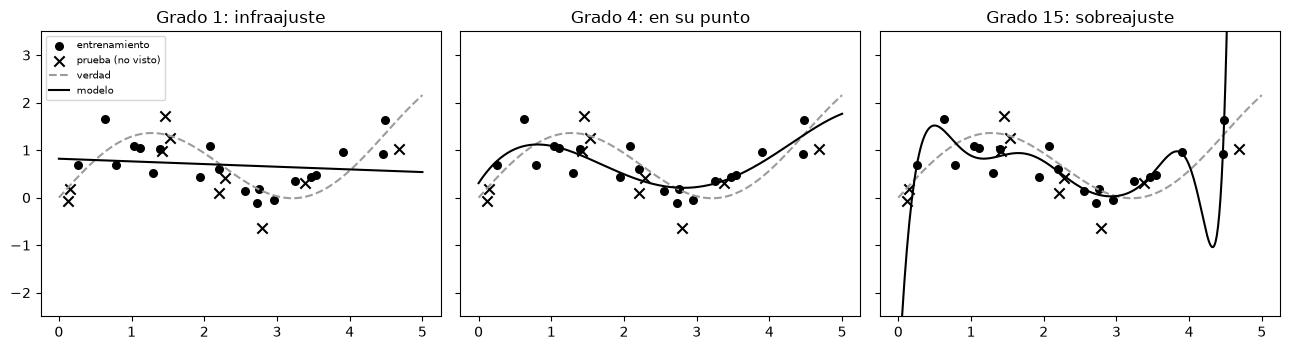

In [3]:
def ajustar(grado, xx, alpha=0.0):
    m = modelo_grado(grado, alpha).fit(x_tr.reshape(-1, 1), y_tr)
    return m.predict(xx.reshape(-1, 1))

malla = np.linspace(0, 5, 300)
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6), sharey=True)
for ax, grado, titulo in zip(axes, [1, 4, 15],
                             ["Grado 1: infraajuste", "Grado 4: en su punto", "Grado 15: sobreajuste"]):
    ax.scatter(x_tr, y_tr, c="black", s=30, label="entrenamiento")
    ax.scatter(x_te, y_te, c="black", marker="x", s=55, label="prueba (no visto)")
    ax.plot(malla, verdad(malla), "--", color="#9c9c9c", label="verdad")
    ax.plot(malla, ajustar(grado, malla), color="black", label="modelo")
    ax.set_title(titulo); ax.set_ylim(-2.5, 3.5)
axes[0].legend(fontsize=7)
plt.tight_layout(); plt.show()


**Mira el panel de la derecha.** El modelo de grado 15 hace cabriolas para tocar cada punto negro de
entrenamiento, pero entre punto y punto se dispara lejísimos de la verdad (la línea gris). Cuando
llegue un dato nuevo (las equis), fallará estrepitosamente. El de la izquierda, en cambio, es tan
rígido que ni siquiera captura la curva. El del centro acierta el equilibrio.


## 3. La curva que lo cuenta todo: error de entrenamiento vs de prueba

Para cada grado, medimos el error en los datos de entrenamiento y en los de prueba. El de
entrenamiento solo **baja**: cuanta más complejidad, mejor memoriza. El de prueba baja... hasta que el
modelo empieza a memorizar ruido, y entonces **sube**. Esa **U** es la firma del sobreajuste, y su
mínimo marca la complejidad óptima.


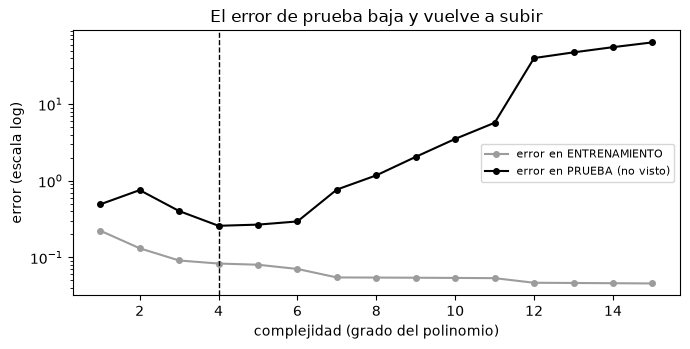

Error de entrenamiento minimo en grado 15 (siempre el mas complejo).
Pero el mejor error de PRUEBA esta en grado 4: ese es el modelo que generaliza.


In [4]:
grados = range(1, 16)
err_tr, err_te = [], []
for g in grados:
    m = modelo_grado(g).fit(x_tr.reshape(-1, 1), y_tr)
    err_tr.append(mean_squared_error(y_tr, m.predict(x_tr.reshape(-1, 1))))
    err_te.append(mean_squared_error(y_te, m.predict(x_te.reshape(-1, 1))))

mejor = int(np.argmin(err_te)) + 1
plt.figure(figsize=(7, 3.6))
plt.plot(list(grados), err_tr, "-o", color="#9c9c9c", label="error en ENTRENAMIENTO", ms=4)
plt.plot(list(grados), err_te, "-o", color="black", label="error en PRUEBA (no visto)", ms=4)
plt.axvline(mejor, ls="--", color="black", lw=1)
plt.yscale("log"); plt.xlabel("complejidad (grado del polinomio)"); plt.ylabel("error (escala log)")
plt.title("El error de prueba baja y vuelve a subir"); plt.legend(fontsize=8)
plt.tight_layout(); plt.show()
print(f"Error de entrenamiento minimo en grado {int(np.argmin(err_tr))+1} (siempre el mas complejo).")
print(f"Pero el mejor error de PRUEBA esta en grado {mejor}: ese es el modelo que generaliza.")


## 4. Por qué pasa: sesgo y varianza

Esa U tiene nombre. El error de un modelo se descompone, conceptualmente, en dos fuentes opuestas:

- **Sesgo (*bias*):** error por ser demasiado simple, por asumir una forma que no es. Domina a la
  izquierda (grados bajos): el modelo *no puede* capturar la curva por mucho que entrene. Es el
  **infraajuste**.
- **Varianza:** error por ser demasiado sensible a los datos concretos de entrenamiento (incluido su
  ruido). Domina a la derecha (grados altos): el modelo cambia muchísimo si cambias un poco los datos.
  Es el **sobreajuste**.

Bajar uno sube el otro: ese es el **compromiso sesgo-varianza**, una de las ideas más profundas del
*machine learning*. El mínimo de la U es el punto donde la suma de ambos es menor. Si solo miraras el
error de entrenamiento (la línea gris, que ignora la varianza), elegirías el modelo más complejo y te
equivocarías de pleno.


## 5. Defensa nº1: más datos

La forma más directa (y a menudo más barata) de combatir el sobreajuste es **dar más datos**. Con
muchos ejemplos, al modelo complejo ya no le compensa memorizar el ruido de unos pocos: la señal pesa
más. Lo medimos entrenando el mismo grado 15 con cada vez más puntos y mirando su error de prueba.


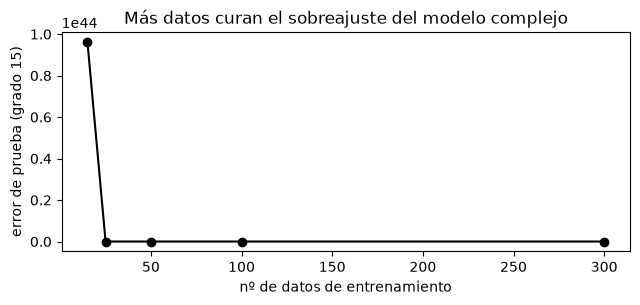

El mismo modelo de grado 15, sobreajustado con pocos datos, generaliza bien con muchos.


In [5]:
def error_test_grado15(n_train):
    rng = np.random.default_rng(0)
    xx = np.sort(rng.uniform(0, 5, n_train + 200))
    yy = verdad(xx) + rng.normal(0, 0.35, len(xx))
    xtr, ytr = xx[:n_train], yy[:n_train]
    xte, yte = xx[n_train:], yy[n_train:]
    m = modelo_grado(15).fit(xtr.reshape(-1,1), ytr)
    return mean_squared_error(yte, m.predict(xte.reshape(-1,1)))

tam = [15, 25, 50, 100, 300]
errs = [error_test_grado15(n) for n in tam]
plt.figure(figsize=(6.5, 3.3))
plt.plot(tam, errs, "-o", color="black")
plt.xlabel("nº de datos de entrenamiento"); plt.ylabel("error de prueba (grado 15)")
plt.title("Más datos curan el sobreajuste del modelo complejo")
plt.tight_layout(); plt.show()
print("El mismo modelo de grado 15, sobreajustado con pocos datos, generaliza bien con muchos.")


## 6. Defensa nº2: regularización

¿Y si no puedes conseguir más datos? Entonces **atas las manos al modelo** para que no se vuelva
loco: la **regularización** penaliza los coeficientes grandes, que son los que producen esas
contorsiones. La regresión *Ridge* añade a la pérdida un término $\alpha\sum w_i^2$: cuanto mayor es
$\alpha$, más suave se obliga a ser el modelo. Tomamos el grado 15 (que sobreajustaba) y le subimos la
regularización: el sobreajuste desaparece sin reducir el grado.


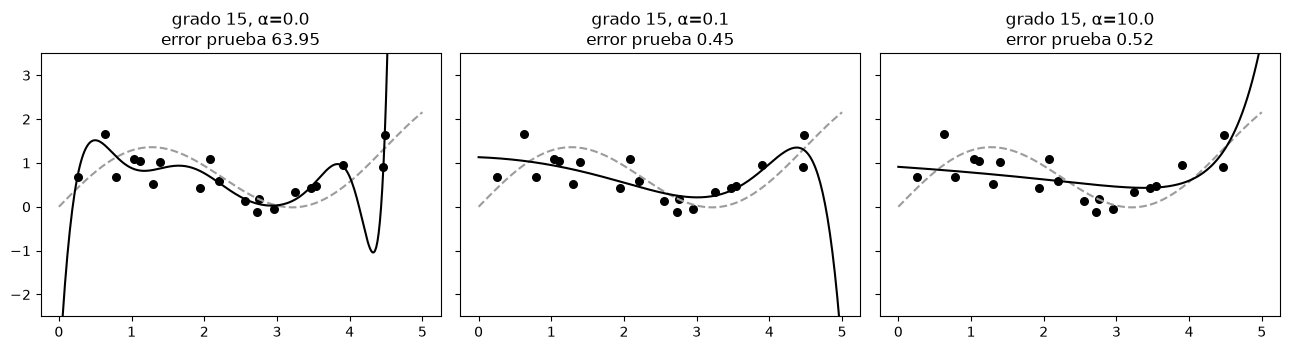

Sin regularizar (α=0) el grado 15 sobreajusta. Con α adecuado, se calma y generaliza.


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6), sharey=True)
for ax, alpha in zip(axes, [0.0, 0.1, 10.0]):
    ax.scatter(x_tr, y_tr, c="black", s=30)
    ax.plot(malla, verdad(malla), "--", color="#9c9c9c")
    ax.plot(malla, ajustar(15, malla, alpha=alpha), color="black")
    et = mean_squared_error(y_te, ajustar(15, x_te, alpha=alpha))
    ax.set_title(f"grado 15, α={alpha}\nerror prueba {et:.2f}"); ax.set_ylim(-2.5, 3.5)
plt.tight_layout(); plt.show()
print("Sin regularizar (α=0) el grado 15 sobreajusta. Con α adecuado, se calma y generaliza.")


## 7. Elegir bien: validación cruzada

Hay un problema sutil: si elegimos la complejidad mirando *nuestro* conjunto de prueba, acabamos
sobreajustando... ¡al test! La forma honesta de elegir es la **validación cruzada**: partir los datos
de entrenamiento en varios pliegues, entrenar en unos y validar en otro, rotando, y promediar. Así la
elección no depende de un único reparto afortunado. La usamos para elegir el grado sin tocar el test.


In [7]:
print("grado | error de validación cruzada (5 pliegues, menor = mejor)")
for g in [1, 2, 4, 6, 10, 15]:
    sc = -cross_val_score(modelo_grado(g), x.reshape(-1,1), y,
                          cv=5, scoring="neg_mean_squared_error").mean()
    print(f"  {g:>2}  | {sc:.3f}   {'#'*int(min(sc,2)*20)}")
print("\nEl grado con menor error de validacion es la eleccion honesta, sin espiar el test.")


grado | error de validación cruzada (5 pliegues, menor = mejor)
   1  | 0.581   ###########
   2  | 2.443   ########################################
   4  | 10.768   ########################################
   6  | 607.127   ########################################
  10  | 3148.477   ########################################
  15  | 122727282.090   ########################################

El grado con menor error de validacion es la eleccion honesta, sin espiar el test.


## 8. Pruébalo tú

1. **Sube el ruido** a `0.8` en `np.random.normal`. ¿Se nota más el sobreajuste? Más ruido = más
   varianza que el modelo complejo puede memorizar por error.
2. **Juega con `alpha`** en la sección 6: prueba 0.001, 1, 100. ¿Cuándo pasa de sobreajuste a
   infraajuste? Demasiada regularización también es mala (vuelve el sesgo).
3. **Cambia la semilla** y repite. La forma de la U se mueve, pero la historia es la misma: hay un
   punto dulce y pasarse se paga.
4. **Combina defensas:** ¿necesitas tanta regularización si tienes 300 datos? Comprueba que con muchos
   datos puedes permitirte modelos más complejos con menos regularización.


## 9. Errores comunes

- **Elegir el modelo por el error de entrenamiento.** Siempre prefiere el más complejo; es la trampa
  clásica. Decide por el error en datos no vistos.
- **Mirar el test muchas veces** para ajustar decisiones: acabas sobreajustando al test. Para eso está
  la validación cruzada; el test se mira **una vez**, al final.
- **Pensar que regularización = peor modelo.** Bien dosificada, casi siempre mejora la generalización.
- **Creer que el sobreajuste es solo de polinomios.** Le pasa a redes neuronales, árboles y LLM. Aquí
  lo ves en pequeño y limpio; en grande, es el mismo fenómeno.


## 10. Qué te llevas

- **Entrenar no es memorizar.** Un error de entrenamiento bajísimo puede ser una trampa; el juez real
  es el error con **datos no vistos**.
- La **curva en U** del error de prueba es el compromiso **sesgo-varianza**: ni demasiado simple
  (infraajuste) ni demasiado complejo (sobreajuste).
- Dos defensas que usarás siempre: **más datos** (cuando puedes) y **regularización** (cuando no). Y
  la **validación cruzada** para elegir sin engañarte.
- Todo esto reaparece, idéntico, en modelos enormes: el sobreajuste no es un problema de juguete, es
  *el* problema de generalizar.

**Para seguir:** el capítulo 7 (pérdidas y optimizadores) explica *cómo* se baja el error; el facsímil
8 entero va de no engañarte con los datos (*leakage*, *splits*); y el facsímil 7, de medir bien para
decidir.


---

### Ficha del cuaderno

- **Obra:** *Inteligencia artificial para gente curiosa* (facsímil interactivo).
- **Web:** https://www.iaparagentecuriosa.686f6c61.dev/
- **Autor:** @686f6c61
- **Fecha:** 2026-06-26
- **Versión:** 1.0

*Material pedagógico. Las salidas que ves son reales: se generan al ejecutar el código, no están escritas a mano. Si cambias algo, cambiarán: esa es la idea.*